In [12]:
from glob import glob
from json import load
result_per_sub = []
for p in glob('results/**/openai/gpt-5-nano/*.json'):
    with open(p, 'r', encoding='utf-8') as fp:
        result_per_sub.append(load(fp))

In [18]:
result_per_sub[0]

{'model_vendor': 'openai',
 'model_name': 'gpt-5-nano',
 'timestamp': '2025-09-24 03:40:21.802489',
 'problem_name': '1083_E',
 'anchor': {'id': '47182602_anchor',
  'source_code': '#include<iostream>\r\n#include <string>\r\n#include<vector>\r\n#include<deque>\r\n#include<queue>\r\n#include<algorithm>\r\nusing namespace std;\r\n\r\nstruct point\r\n{\r\n\tlong long x, y, a;\r\n\r\n\tint i, op;\r\n};\r\n\r\n\r\n\r\ndeque<point> bucket[2][256];\r\n\r\nvoid rsort(vector<point >& v) {\r\n\tunsigned long  i, k;\r\n\tfor (i = 0; i < v.size(); ++i)\r\n\t\tbucket[0][v[i].x & 0x000000ff].push_back(v[i]);\r\n\r\n\tfor (i = 0; i < 256; ++i) {\r\n\t\twhile (!bucket[0][i].empty()) {\r\n\t\t\tpoint  &e = bucket[0][i].front();\r\n\t\t\tbucket[1][(e.x & 0x0000ff00) >> 8].push_back(e);\r\n\t\t\tbucket[0][i].pop_front();\r\n\t\t}\r\n\t}\r\n\tfor (i = 0; i < 256; ++i) {\r\n\t\twhile (!bucket[1][i].empty()) {\r\n\t\t\tpoint  &e = bucket[1][i].front();\r\n\t\t\tbucket[0][(e.x & 0x00ff0000) >> 16].push_back(

In [46]:
import difflib

def preprocess(s:str):
    return s.replace('\t', '')

def count_differences(source_a:str, source_b:str):
    lines_a = preprocess(source_a).splitlines()
    lines_b = preprocess(source_b).splitlines()

    lines_a = [l for l in lines_a if l != '']
    lines_b = [l for l in lines_b if l != '']

    diff_lines = list(difflib.unified_diff(lines_a, lines_b, "Modified", "Original"))

    additions = 0
    deletions = 0
    
    # Parse diff lines to count additions and deletions
    for line in diff_lines:
        if line.startswith('+') and not line.startswith('+++'):
            additions += 1
        elif line.startswith('-') and not line.startswith('---'):
            deletions += 1

    return additions, deletions

In [48]:
import pandas as pd

results = {"sub_id":[],
           "problem_name":[],
           "additions_base":[],
           "deletions_base":[],
           "additions_fixed":[],
           "deletions_fixed":[],
           "additions_gen":[],
           "deletions_gen":[],
           }

for r in result_per_sub:
    if r['anchor']['result'] is False or r['original']['result'] is True:
        continue
    problem_name = r['problem_name']
    sub_id = r['original']['id']

    anchor_source_code = r['anchor']['source_code'].replace('\r\n', '\n')
    original_source_code = r['original']['source_code'].replace('\r\n', '\n')
    llm_fix_code = r['llm_fix_code']['source_code']
    llm_generate_code = r['llm_generate_code']['source_code']

   
    results['sub_id'].append(sub_id)
    results['problem_name'].append(problem_name)

    additions, deletions = count_differences(original_source_code, anchor_source_code)

    results['additions_base'].append(additions)
    results['deletions_base'].append(deletions)

    additions, deletions = count_differences(llm_fix_code, anchor_source_code)

    results['additions_fixed'].append(additions)
    results['deletions_fixed'].append(deletions)

    additions, deletions = count_differences(llm_generate_code, anchor_source_code)

    results['additions_gen'].append(additions)
    results['deletions_gen'].append(deletions)

results = pd.DataFrame(results)
    
results['sum_base'] = results['additions_base'] + results['deletions_base']
results['sum_fixed'] = results['additions_fixed'] + results['deletions_fixed']
results['sum_gen'] = results['additions_gen'] + results['deletions_gen']

results.to_csv('results/results.csv', index=False)
    

Text(0.5, 1.0, 'Number modifications sample')

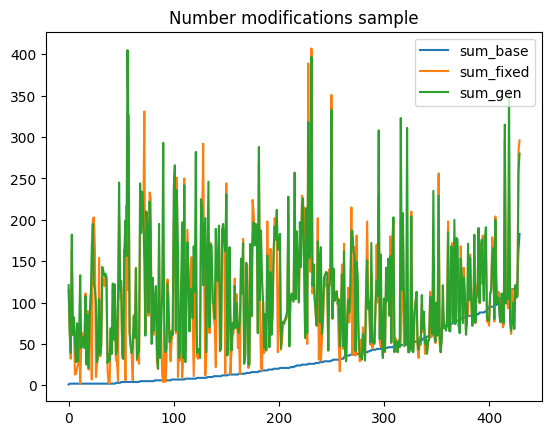

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv('results/results.csv')

df = df.sort_values('sum_base')

plt.plot(np.arange(len(df)), df['sum_base'],  label = 'sum_base')
plt.plot(np.arange(len(df)), df['sum_fixed'], label = 'sum_fixed')
plt.plot(np.arange(len(df)), df['sum_gen'],  label = 'sum_gen')
plt.legend()
plt.title("Number modifications sample")